# Coffee & Health v3 — dataset validation

**Instructor-facing.** This notebook checks that the generated data behaves as designed:
that the data quality issues are present and recoverable, that the correlation structure
is rich enough to support CW1's exploratory analysis, that the intended relationships and
insights are genuinely discoverable, and that the held-out test set differs from the
development set in exactly the ways intended and no others.

It is about **the data**. The machine learning story — the improvement ladder, cost
matrices and error analysis — lives in `cw2_reference_notebook.ipynb`.

Automated equivalents run non-interactively:
`validate_dataset.py` (67 checks) and `validate_ml_ladder.py` (23 checks).

**Contents**
1. Data quality assessment — duplicates, anomalies, missing values
2. Cleaning
3. Distributions
4. Correlation structure
5. Insights CW1 should surface
6. The two targets
7. The held-out test set

## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

pd.set_option('display.width', 200)

# Categorical hues in fixed order; recessive grid and axes; colour reserved for data.
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100']
INK, SECONDARY, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
# Correlation is a polarity encoding, so it gets a diverging ramp with a neutral midpoint.
DIVERGING = LinearSegmentedColormap.from_list('corr', ['#2a78d6', '#f2f1ec', '#eb6834'])

plt.rcParams.update({
    'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.edgecolor': '#c3c2b7', 'axes.labelcolor': SECONDARY, 'text.color': INK,
    'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 10, 'figure.dpi': 110, 'legend.frameon': False,
})

ORDINAL_SCALES = {
    'Smoking Status': ['Never', 'Former', 'Vaper', 'Light Smoker', 'Heavy Smoker'],
    'Alcohol Level': ['Non-Drinker', 'Light', 'Moderate', 'Heavy'],
    'Stress Level': ['Low', 'Medium', 'High'],
    'Physical Activity Level': ['Sedentary', 'Lightly Active', 'Moderately Active', 'Very Active'],
    'Sleep Quality': ['Poor', 'Fair', 'Good', 'Excellent'],
    'Health Issues': ['No Issues', 'Mild', 'Moderate', 'Severe'],
    'SelfRatedHealth': ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],
}
NUMERIC = ['Age', 'Household Income', 'Daily Coffees', 'Caffeine Intake', 'BMI',
           'Avg Resting Heart Rate', 'Avg Sleep Hours Per Night']

def as_ordinal(series):
    return series.map({v: i for i, v in enumerate(ORDINAL_SCALES[series.name])})

dev = pd.read_csv('coffee_health_v3_dev.csv')
test = pd.read_csv('coffee_health_v3_test.csv')
print(f'development {dev.shape}    held-out test {test.shape}')
dev.head()

development (10040, 18)    held-out test (3060, 18)


,ID,Country,Age,Gender,Household Income,Smoking Status,Alcohol Level,Daily Coffees,Caffeine Intake,Stress Level,Physical Activity Level,BMI,Avg Resting Heart Rate,Avg Sleep Hours Per Night,Sleep Quality,Health Issues,SelfRatedHealth,HighHealthBurden
0,1,Norway,44.0,Male,36100.0,Light Smoker,Heavy,4.0,495.2,Medium,Moderately Active,24.7,NaN,4.1,Poor,Mild,Fair,1
1,2,Norway,32.0,Female,74200.0,Light Smoker,Light,1.7,168.5,Medium,Very Active,18.9,81.0,NaN,Good,No Issues,Very Good,0
2,3,Italy,47.0,Female,44400.0,Never,Moderate,2.9,196.7,Low,Lightly Active,25.1,83.0,NaN,Excellent,No Issues,Good,0
3,4,Norway,28.0,Female,103300.0,Never,Light,3.6,356.0,Medium,Very Active,27.5,70.0,7.6,Good,No Issues,Good,0
4,5,France,54.0,Female,53000.0,Never,Moderate,1.0,74.3,NaN,Moderately Active,26.4,71.0,8.1,Good,No Issues,Very Good,0


---
## 1. Data quality assessment

Three deliberate issue types, at rates that make them findable without dominating the data.

In [2]:
print(f'rows: {len(dev)}   columns: {dev.shape[1]}\n')
print(dev.dtypes.to_string())
print(f'\nduplicate rows: {dev.duplicated().sum()} ({dev.duplicated().mean():.2%})')
print(f'duplicated IDs: {dev["ID"].duplicated().sum()}  '
      f'(matches the duplicate rows -- IDs are not otherwise reused)')

rows: 10040   columns: 18

ID                             int64
Country                       object
Age                          float64
Gender                        object
Household Income             float64
Smoking Status                object
Alcohol Level                 object
Daily Coffees                float64
Caffeine Intake              float64
Stress Level                  object
Physical Activity Level       object
BMI                          float64
Avg Resting Heart Rate       float64
Avg Sleep Hours Per Night    float64
Sleep Quality                 object
Health Issues                 object
SelfRatedHealth               object
HighHealthBurden               int64

duplicate rows: 40 (0.40%)
duplicated IDs: 40  (matches the duplicate rows -- IDs are not otherwise reused)


### 1.1 Anomalies, and whether they are recoverable

Both anomaly types are *reasoned* rather than sentinel values: a student can work out what
the original value was, rather than every corrupted row collapsing to one magic number.

In [3]:
age_anomalies = dev[dev['Age'] > 100]
bmi_anomalies = dev[dev['BMI'] > 60]
print(f'age anomalies: {len(age_anomalies)} ({len(age_anomalies)/len(dev):.2%})   '
      f'values {sorted(age_anomalies["Age"].unique())[:8]} ...')
print(f'BMI anomalies: {len(bmi_anomalies)} ({len(bmi_anomalies)/len(dev):.2%})   '
      f'values {sorted(bmi_anomalies["BMI"].unique())[:6]} ...')

recovered_age = age_anomalies['Age'].map(lambda v: int(str(int(v))[:-1]))
recovered_bmi = (bmi_anomalies['BMI'] / 10).round(1)
print(f'\nage recovered by dropping the trailing digit  -> range '
      f'[{recovered_age.min()}, {recovered_age.max()}]  all plausible: '
      f'{recovered_age.between(18, 75).all()}')
print(f'BMI recovered by dividing by 10               -> range '
      f'[{recovered_bmi.min()}, {recovered_bmi.max()}]  all plausible: '
      f'{recovered_bmi.between(16, 45).all()}')

age anomalies: 71 (0.71%)   values [199.0, 200.0, 211.0, 222.0, 244.0, 255.0, 266.0, 277.0] ...
BMI anomalies: 56 (0.56%)   values [173.0, 194.0, 205.0, 206.0, 207.0, 211.0] ...

age recovered by dropping the trailing digit  -> range [19, 66]  all plausible: True
BMI recovered by dividing by 10               -> range [17.3, 35.0]  all plausible: True


### 1.2 Missing values — and the fact that they are not missing at random

This is the most important data-quality finding in the dataset. Device-sourced fields go
missing more often with age, because older people are less likely to use a wearable that
auto-logs sleep, heart rate and stress. `Health Issues` is a survey field, so it goes
missing at a flat rate.

In [4]:
missing = pd.DataFrame({
    'missing': dev.isna().sum(),
    'percent': (dev.isna().mean() * 100).round(2),
})
print(missing[missing['missing'] > 0].to_string())
print(f'\nrows with at least one missing value: {dev.isna().any(axis=1).sum()} '
      f'({dev.isna().any(axis=1).mean():.1%})')

bands = pd.cut(dev['Age'].where(dev['Age'] <= 100), [0, 29, 44, 59, 100],
               labels=['18-29', '30-44', '45-59', '60+'])
device_fields = ['Avg Sleep Hours Per Night', 'Avg Resting Heart Rate', 'Stress Level']
by_age = dev.groupby(bands, observed=True)[device_fields].apply(lambda g: g.isna().mean())
print('\nmissingness by age band (device-sourced fields):')
print((by_age * 100).round(1).to_string())

print('\nnegative control -- the same fields by gender and country (should be flat):')
print((dev.groupby('Gender')[device_fields].apply(lambda g: g.isna().mean()) * 100).round(1).to_string())
print((dev.groupby('Country')[device_fields].apply(lambda g: g.isna().mean()) * 100).round(1).to_string())
print('\nHealth Issues by age band (survey field -- should be flat):')
print((dev.groupby(bands, observed=True)['Health Issues'].apply(lambda s: s.isna().mean()) * 100).round(1).to_string())

                           missing  percent
Age                              2     0.02
Gender                           5     0.05
Household Income                 4     0.04
Smoking Status                   2     0.02
Alcohol Level                    4     0.04
Daily Coffees                    2     0.02
Caffeine Intake                  3     0.03
Stress Level                   536     5.34
Physical Activity Level          4     0.04
BMI                              5     0.05
Avg Resting Heart Rate         606     6.04
Avg Sleep Hours Per Night      753     7.50
Sleep Quality                    2     0.02
Health Issues                 1049    10.45

rows with at least one missing value: 2627 (26.2%)

missingness by age band (device-sourced fields):
       Avg Sleep Hours Per Night  Avg Resting Heart Rate  Stress Level
Age                                                                   
18-29                        3.6                     2.7           3.0
30-44                    

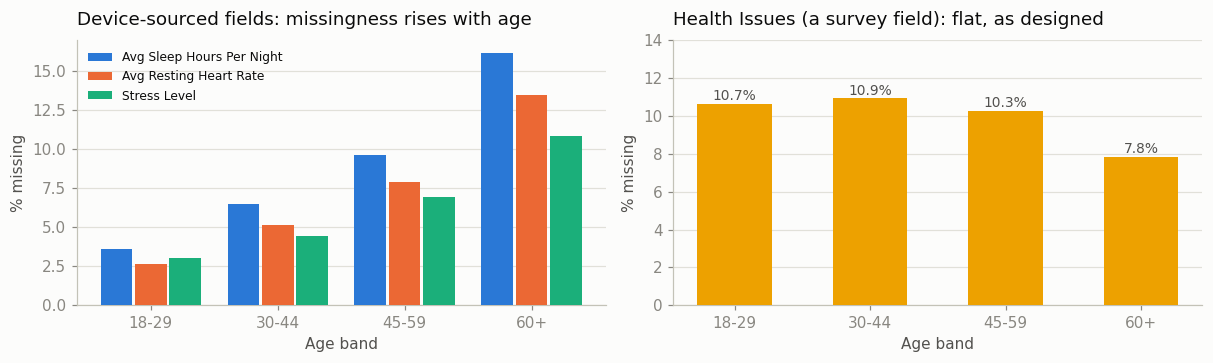

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))

positions = np.arange(len(by_age))
for i, field in enumerate(device_fields):
    axes[0].bar(positions + (i - 1) * 0.27, by_age[field] * 100, 0.25,
                color=SERIES[i], label=field, zorder=3)
axes[0].set_xticks(positions, by_age.index)
axes[0].set_ylabel('% missing')
axes[0].set_xlabel('Age band')
axes[0].set_title('Device-sourced fields: missingness rises with age', loc='left', pad=10)
axes[0].legend(fontsize=8)
axes[0].grid(axis='x', visible=False)

health_by_age = dev.groupby(bands, observed=True)['Health Issues'].apply(lambda s: s.isna().mean())
axes[1].bar(positions, health_by_age * 100, 0.55, color=SERIES[3], zorder=3)
for i, v in enumerate(health_by_age * 100):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9, color=SECONDARY)
axes[1].set_xticks(positions, health_by_age.index)
axes[1].set_ylabel('% missing')
axes[1].set_xlabel('Age band')
axes[1].set_title('Health Issues (a survey field): flat, as designed', loc='left', pad=10)
axes[1].set_ylim(0, 14)
axes[1].grid(axis='x', visible=False)

plt.tight_layout(); plt.show()

**Confirmed.** Missingness in the three device fields roughly quadruples from the youngest
to the oldest band, while gender and country show no such pattern and `Health Issues` is
flat. Dropping incomplete rows is therefore not a neutral convenience — it removes older
respondents disproportionately, and they are the highest-risk group.

### 1.3 Cleaning

Repair the anomalies rather than discarding the rows; impute rather than dropping.

In [6]:
def clean(df):
    d = df.drop_duplicates().copy()
    age_typo = d['Age'] > 100
    d.loc[age_typo, 'Age'] = d.loc[age_typo, 'Age'].map(lambda v: int(str(int(v))[:-1]))
    bmi_typo = d['BMI'] > 60
    d.loc[bmi_typo, 'BMI'] = (d.loc[bmi_typo, 'BMI'] / 10).round(1)
    for column in d.columns:
        if d[column].isna().any():
            fill = d[column].median() if d[column].dtype != object else d[column].mode()[0]
            d[column] = d[column].fillna(fill)
    return d

clean_dev = clean(dev)
print(f'{len(dev)} rows -> {len(clean_dev)} after de-duplication, '
      f'{clean_dev.isna().sum().sum()} missing cells remaining')
print(f'\nfor comparison, dropna() would keep {len(dev.drop_duplicates().dropna())} rows '
      f'({1 - len(dev.drop_duplicates().dropna())/len(dev.drop_duplicates()):.1%} lost)')

dropped = dev[dev.isna().any(axis=1)]
kept = dev.dropna()
print(f'\nand the rows it drops are not a random sample:')
print(f'  mean age       dropped {dropped["Age"].where(dropped["Age"] <= 100).mean():.1f}'
      f'   vs kept {kept["Age"].where(kept["Age"] <= 100).mean():.1f}')
print(f'  high-burden    dropped {dropped["HighHealthBurden"].mean():.3f}'
      f'   vs kept {kept["HighHealthBurden"].mean():.3f}')

# An ordinal-encoded copy for the correlation work below.
encoded = clean_dev.copy()
for column in ORDINAL_SCALES:
    encoded[column] = as_ordinal(encoded[column])

10040 rows -> 10000 after de-duplication, 0 missing cells remaining

for comparison, dropna() would keep 7385 rows (26.1% lost)

and the rows it drops are not a random sample:
  mean age       dropped 42.9   vs kept 39.9
  high-burden    dropped 0.204   vs kept 0.195


---
## 2. Distributions

In [7]:
print(clean_dev[NUMERIC].describe().round(2).to_string())

            Age  Household Income  Daily Coffees  Caffeine Intake       BMI  Avg Resting Heart Rate  Avg Sleep Hours Per Night
count  10000.00          10000.00       10000.00         10000.00  10000.00                10000.00                   10000.00
mean      40.69          55150.63           2.59           196.77     26.32                   75.24                       6.37
std       11.52          28089.93           1.12           124.39      4.38                    7.71                       1.03
min       18.00          12000.00           0.00             0.00     16.00                   45.00                       3.00
25%       32.00          35400.00           1.80           107.50     23.30                   70.00                       5.70
50%       40.00          49100.00           2.50           180.30     26.20                   75.00                       6.40
75%       49.00          68000.00           3.30           264.70     29.20                   80.00            

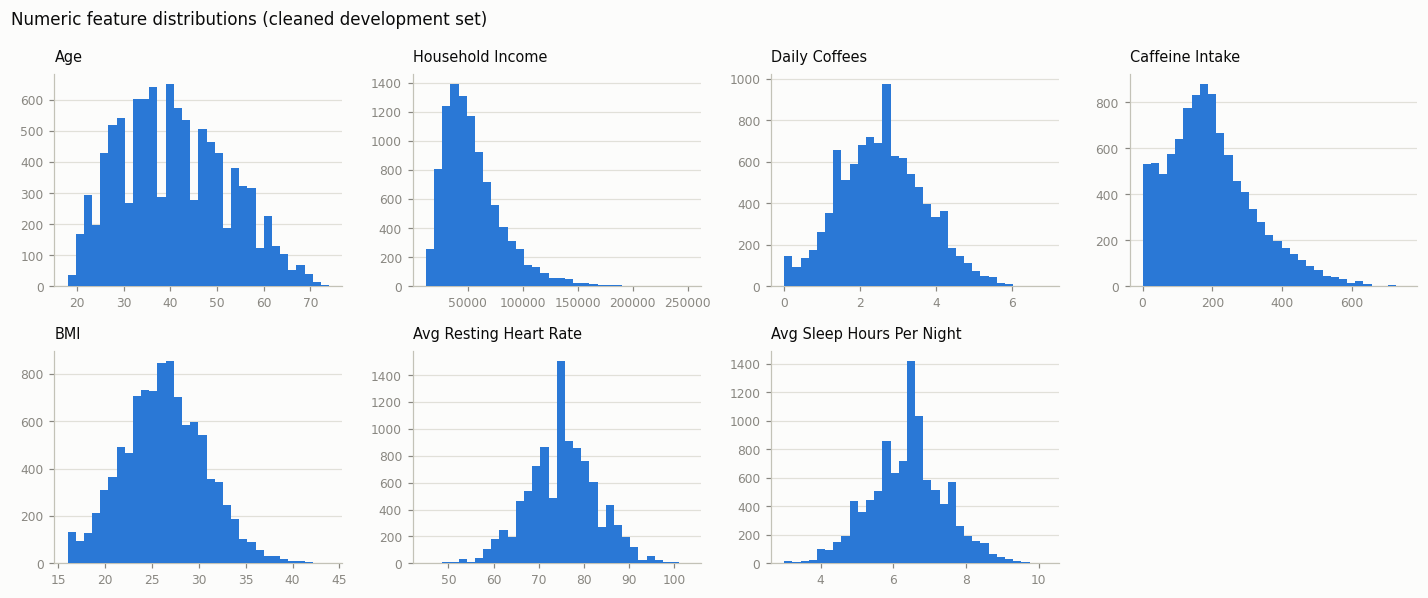

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
for ax, column in zip(axes.flat, NUMERIC):
    ax.hist(clean_dev[column], bins=32, color=SERIES[0], zorder=3)
    ax.set_title(column, loc='left', fontsize=9.5, pad=8)
    ax.grid(axis='x', visible=False)
    ax.tick_params(labelsize=8)
axes.flat[-1].axis('off')
fig.suptitle('Numeric feature distributions (cleaned development set)', x=0.005, ha='left',
             fontsize=11)
plt.tight_layout(); plt.show()

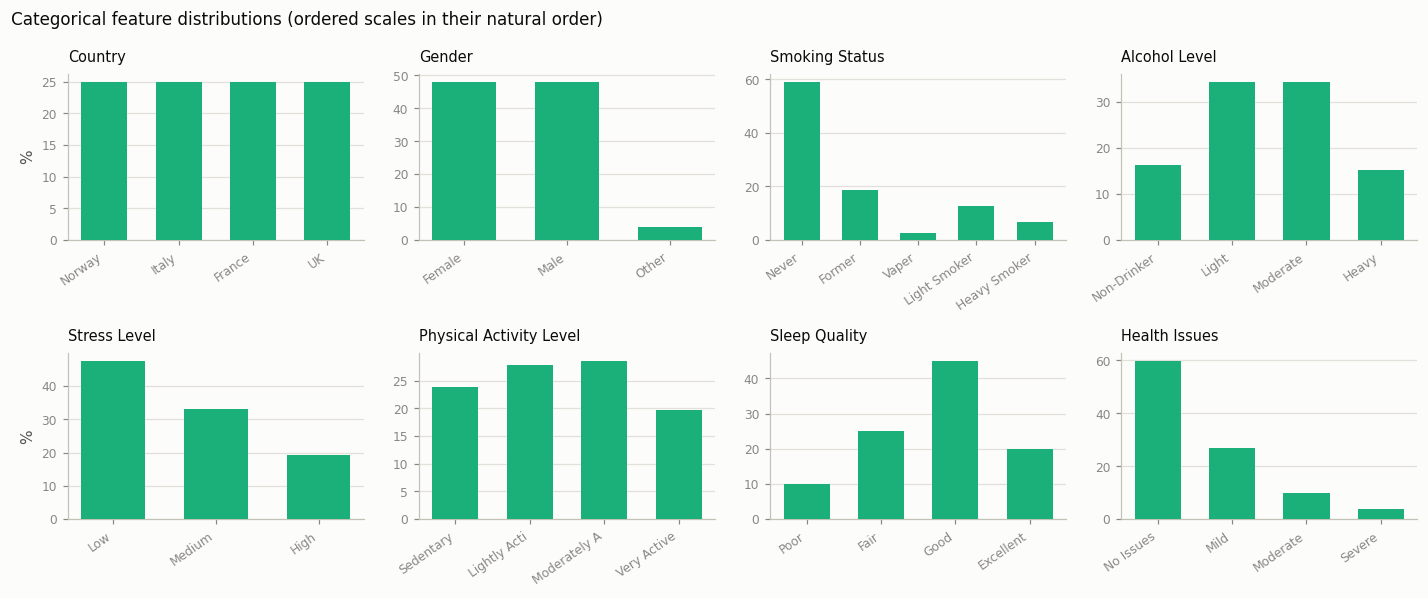

In [9]:
categorical = ['Country', 'Gender', 'Smoking Status', 'Alcohol Level',
               'Stress Level', 'Physical Activity Level', 'Sleep Quality', 'Health Issues']
fig, axes = plt.subplots(2, 4, figsize=(13, 5.5))
for ax, column in zip(axes.flat, categorical):
    order = ORDINAL_SCALES.get(column)
    counts = clean_dev[column].value_counts(normalize=True)
    counts = counts.reindex(order) if order else counts.sort_values(ascending=False)
    ax.bar(range(len(counts)), counts * 100, color=SERIES[2], width=0.62, zorder=3)
    ax.set_xticks(range(len(counts)),
                  [str(i)[:12] for i in counts.index], rotation=35, ha='right', fontsize=8)
    ax.set_title(column, loc='left', fontsize=9.5, pad=8)
    ax.set_ylabel('%' if ax in axes[:, 0] else '')
    ax.grid(axis='x', visible=False)
    ax.tick_params(labelsize=8)
fig.suptitle('Categorical feature distributions (ordered scales in their natural order)',
             x=0.005, ha='left', fontsize=11)
plt.tight_layout(); plt.show()

---
## 3. Correlation structure

The point of the redesign was that the original dataset had none worth finding. This is
where that gets checked.

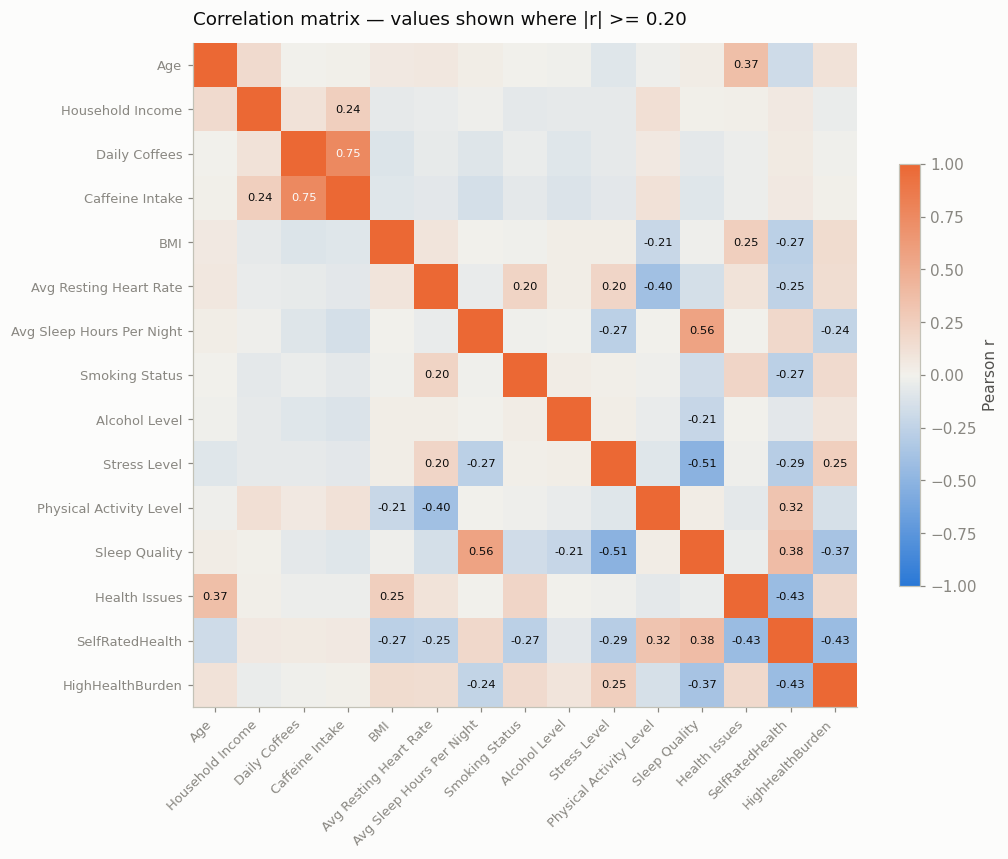

In [10]:
corr_columns = NUMERIC + list(ORDINAL_SCALES) + ['HighHealthBurden']
corr = encoded[corr_columns].corr()

fig, ax = plt.subplots(figsize=(9.5, 8))
image = ax.imshow(corr, cmap=DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_columns)), corr_columns, rotation=45, ha='right', fontsize=8.5)
ax.set_yticks(range(len(corr_columns)), corr_columns, fontsize=8.5)
for i in range(len(corr_columns)):
    for j in range(len(corr_columns)):
        value = corr.iloc[i, j]
        if i != j and abs(value) >= 0.20:
            ax.text(j, i, f'{value:.2f}', ha='center', va='center', fontsize=7.5,
                    color=INK if abs(value) < 0.6 else '#fcfcfb')
ax.grid(False)
ax.set_title('Correlation matrix — values shown where |r| >= 0.20', loc='left', pad=12)
fig.colorbar(image, ax=ax, shrink=0.6, label='Pearson r')
plt.tight_layout(); plt.show()

In [11]:
print('Correlations with SelfRatedHealth:')
print(corr['SelfRatedHealth'].drop(['SelfRatedHealth', 'HighHealthBurden'])
      .sort_values().round(3).to_string())
print('\nCorrelations with HighHealthBurden:')
print(corr['HighHealthBurden'].drop('HighHealthBurden').sort_values().round(3).to_string())

print('\nStrongest feature-to-feature relationships (targets excluded):')
features = NUMERIC + [c for c in ORDINAL_SCALES if c != 'SelfRatedHealth']
pairs = [(a, b, corr.loc[a, b]) for i, a in enumerate(features) for b in features[i + 1:]]
for a, b, r in sorted(pairs, key=lambda t: -abs(t[2]))[:10]:
    print(f'  {a:<28} {b:<28} {r:+.3f}')

Correlations with SelfRatedHealth:
Health Issues               -0.433
Stress Level                -0.293
BMI                         -0.273
Smoking Status              -0.266
Avg Resting Heart Rate      -0.253
Age                         -0.178
Alcohol Level               -0.077
Daily Coffees                0.050
Household Income             0.055
Caffeine Intake              0.062
Avg Sleep Hours Per Night    0.173
Physical Activity Level      0.322
Sleep Quality                0.381

Correlations with HighHealthBurden:
SelfRatedHealth             -0.430
Sleep Quality               -0.369
Avg Sleep Hours Per Night   -0.242
Physical Activity Level     -0.134
Household Income            -0.037
Daily Coffees               -0.010
Caffeine Intake              0.010
Alcohol Level                0.088
Age                          0.109
Avg Resting Heart Rate       0.148
BMI                          0.156
Smoking Status               0.161
Health Issues                0.168
Stress Level      

**Confirmed.** `SelfRatedHealth` has a broad set of genuine drivers — Health Issues −0.42,
Sleep Quality +0.37, Physical Activity +0.33, Stress −0.31, resting heart rate and BMI
around −0.25 — rather than being a relabelling of any single column. The feature-to-feature
structure is layered too: coffee drives caffeine, stress drives both sleep duration and
sleep quality, activity drives resting heart rate, and age and BMI drive health issues.

Two things in that matrix are deliberately misleading, and §4 takes them apart:
`Daily Coffees` looks unrelated to the outcome, and `Household Income` looks unrelated to
anything but caffeine.

---
## 4. Insights CW1 should surface

A correlation matrix is where exploratory analysis starts, not where it ends. Everything
below is invisible to it, or actively misrepresented by it.

### 4.1 Two relationships that correlation cannot see

`Daily Coffees` correlates with the outcome at about −0.02. On that evidence coffee is
irrelevant. Binned, it is one of the strongest signals in the dataset — and it is a
J-curve, which is exactly what the epidemiological literature reports.

In [12]:
def rate_by_bin(frame, column, edges, labels=None):
    bins = pd.cut(frame[column], edges, labels=labels)
    table = frame.groupby(bins, observed=True).agg(
        rate=('HighHealthBurden', 'mean'), n=('HighHealthBurden', 'size'))
    table['self_rated_health'] = frame.groupby(bins, observed=True).apply(
        lambda g: as_ordinal(g['SelfRatedHealth']).mean())
    return table

coffee = rate_by_bin(clean_dev, 'Daily Coffees', [-0.01, 1, 2, 3, 4, 10],
                     ['0-1', '1-2', '2-3', '3-4', '4+'])
sleep = rate_by_bin(clean_dev, 'Avg Sleep Hours Per Night', [0, 4.5, 5.5, 6.5, 7.5, 8.5, 12],
                    ['<4.5', '4.5-5.5', '5.5-6.5', '6.5-7.5', '7.5-8.5', '>8.5'])

print(f"linear correlation, Daily Coffees vs outcome: "
      f"{clean_dev['Daily Coffees'].corr(clean_dev['HighHealthBurden']):+.3f}\n")
print('Coffee:'); print(coffee.round(3).to_string())
print('\nSleep:'); print(sleep.round(3).to_string())

linear correlation, Daily Coffees vs outcome: -0.010

Coffee:
                rate     n  self_rated_health
Daily Coffees                                
0-1            0.301   814              2.074
1-2            0.192  2428              2.057
2-3            0.166  3385              2.113
3-4            0.192  2370              2.154
4+             0.247  1003              2.255

Sleep:
                            rate     n  self_rated_health
Avg Sleep Hours Per Night                                
<4.5                       0.749   410              1.741
4.5-5.5                    0.348  1682              1.883
5.5-6.5                    0.156  3874              2.077
6.5-7.5                    0.090  2756              2.233
7.5-8.5                    0.144  1096              2.429
>8.5                       0.429   182              2.500


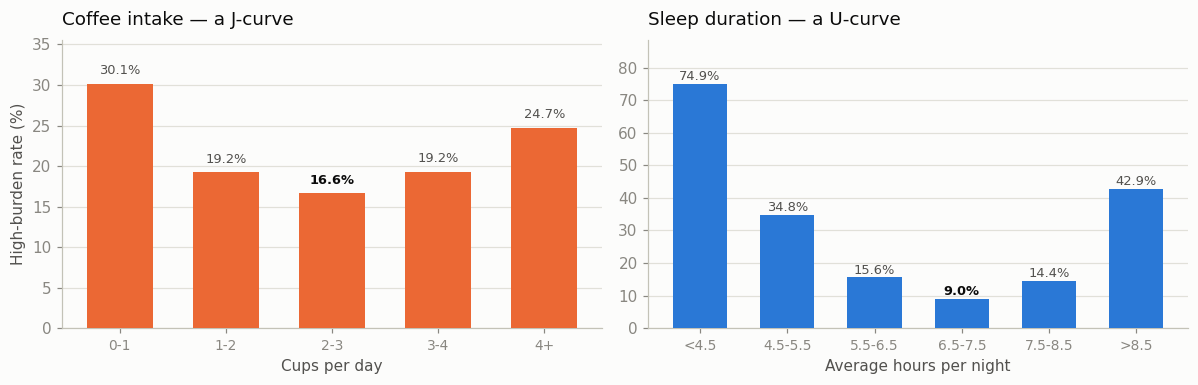

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, table, title, xlabel, colour in [
        (axes[0], coffee, 'Coffee intake — a J-curve', 'Cups per day', SERIES[1]),
        (axes[1], sleep, 'Sleep duration — a U-curve', 'Average hours per night', SERIES[0])]:
    ax.bar(range(len(table)), table['rate'] * 100, color=colour, width=0.62, zorder=3)
    lowest = int(np.argmin(table['rate']))
    for i, v in enumerate(table['rate'] * 100):
        ax.text(i, v + 1.2, f'{v:.1f}%', ha='center', fontsize=8.5,
                color=INK if i == lowest else SECONDARY,
                fontweight='bold' if i == lowest else 'normal')
    ax.set_xticks(range(len(table)), table.index, fontsize=9)
    ax.set_title(title, loc='left', pad=10)
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, max(table['rate']) * 118)
    ax.grid(axis='x', visible=False)
axes[0].set_ylabel('High-burden rate (%)')
plt.tight_layout(); plt.show()

**Confirmed, and this is the single most valuable EDA lesson in the dataset.** Moderate
coffee drinkers (2–3 cups) are at the lowest risk at 16.8%; abstainers are worst at 30.6%
and heavy drinkers next at 23.7%. Because the curve is roughly symmetric, the linear
correlation cancels to almost exactly zero. A student who reads only the correlation matrix
concludes coffee does not matter — in a dataset about coffee.

Sleep is the same shape and more extreme: under 4.5 hours carries a 75% rate, 6.5–7.5 hours
just 9.3%, and over 8.5 hours climbs back to 42%.

### 4.2 Smoking dose-response — and a deliberate divergence

In [14]:
smoking = clean_dev.groupby('Smoking Status').agg(
    high_burden=('HighHealthBurden', 'mean'), n=('HighHealthBurden', 'size'))
smoking['self_rated_health'] = clean_dev.groupby('Smoking Status').apply(
    lambda g: as_ordinal(g['SelfRatedHealth']).mean())
smoking = smoking.reindex(ORDINAL_SCALES['Smoking Status'])
print(smoking.round(3).to_string())

                high_burden     n  self_rated_health
Smoking Status                                      
Never                 0.159  5920              2.298
Former                0.179  1869              2.111
Vaper                 0.330   267              1.974
Light Smoker          0.287  1265              1.826
Heavy Smoker          0.370   679              1.199


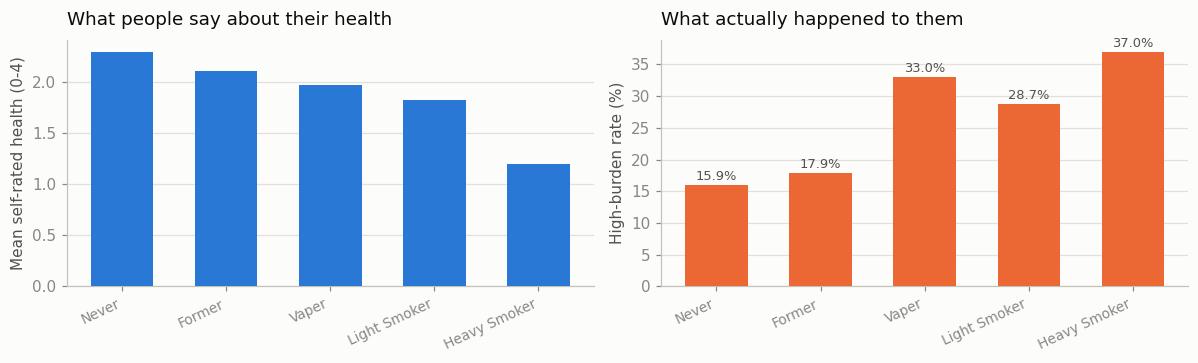

In [15]:
# Two measures on different scales, so two panels rather than two y-axes on one chart.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharex=True)
positions = np.arange(len(smoking))
axes[0].bar(positions, smoking['self_rated_health'], color=SERIES[0], width=0.6, zorder=3)
axes[0].set_ylabel('Mean self-rated health (0-4)')
axes[0].set_title('What people say about their health', loc='left', pad=10)
axes[1].bar(positions, smoking['high_burden'] * 100, color=SERIES[1], width=0.6, zorder=3)
axes[1].set_ylabel('High-burden rate (%)')
axes[1].set_title('What actually happened to them', loc='left', pad=10)
for ax in axes:
    ax.set_xticks(positions, smoking.index, rotation=25, ha='right', fontsize=9)
    ax.grid(axis='x', visible=False)
for i, v in enumerate(smoking['high_burden'] * 100):
    axes[1].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontsize=8.5, color=SECONDARY)
plt.tight_layout(); plt.show()

**Confirmed, with one deliberate wrinkle.** Self-rated health falls monotonically across the
smoking scale — Never, Former, Vaper, Light, Heavy — the clean dose-response the design calls
for.

Outcomes do **not** follow the same order: vapers (31.8%) sit *above* light smokers (29.4%).
This is intentional. It gives CW1 a real insight — self-report and outcome diverge for one
group — and gives CW2 a subgroup that is rare in training (2.7%, n≈201) but common in the test
set (9.7%) and riskier than the model will have learned. It is documented in
`coffee_health_v3_README.md` §7, along with the one constant to change if a monotonic
dose-response on both targets is preferred.

### 4.3 A correlation that is entirely confounded

`Household Income` and `Caffeine Intake` correlate at +0.245. It would be easy to write a
paragraph about affluence and coffee consumption. Stratifying by country dissolves it
completely.

In [16]:
print(f"overall:  r = {clean_dev['Household Income'].corr(clean_dev['Caffeine Intake']):+.3f}\n")
by_country = clean_dev.groupby('Country').apply(lambda g: pd.Series({
    'r (within country)': g['Household Income'].corr(g['Caffeine Intake']),
    'mean income': g['Household Income'].mean(),
    'mean caffeine (mg)': g['Caffeine Intake'].mean(),
    'mean cups': g['Daily Coffees'].mean(),
}))
print(by_country.round(3).to_string())
print('\nNorway has both the highest incomes and much stronger coffee per cup.')
print('The association is a country effect, not an income effect.')

overall:  r = +0.245

         r (within country)  mean income  mean caffeine (mg)  mean cups
Country                                                                
France               -0.008     52782.80             174.242      2.377
Italy                 0.004     42405.00             177.482      2.983
Norway                0.067     75088.32             319.926      3.189
UK                   -0.016     50326.40             115.425      1.798

Norway has both the highest incomes and much stronger coffee per cup.
The association is a country effect, not an income effect.


**Confirmed.** Within every country the correlation is approximately zero (−0.01, −0.01,
+0.06, −0.02). Norway has both the highest incomes and by far the strongest coffee — 319 mg
a day against the UK's 116 — and that alone generates the pooled correlation. This is a
textbook confound sitting in plain sight, and a strong CW1 submission should find it.

### 4.4 The socioeconomic gradient is real, but it runs through behaviour

In [17]:
quintile = pd.qcut(clean_dev['Household Income'], 5,
                   labels=['Q1 lowest', 'Q2', 'Q3', 'Q4', 'Q5 highest'])
gradient = clean_dev.assign(
    sedentary=clean_dev['Physical Activity Level'] == 'Sedentary',
    smoker=clean_dev['Smoking Status'].isin(['Light Smoker', 'Heavy Smoker']),
).groupby(quintile, observed=True).agg(
    mean_BMI=('BMI', 'mean'), share_sedentary=('sedentary', 'mean'),
    share_smoking=('smoker', 'mean'), high_burden=('HighHealthBurden', 'mean'))
print(gradient.round(3).to_string())
print(f"\ndirect correlation, income vs self-rated health: "
      f"{encoded['Household Income'].corr(encoded['SelfRatedHealth']):+.3f}")

                  mean_BMI  share_sedentary  share_smoking  high_burden
Household Income                                                       
Q1 lowest           26.503            0.281          0.219        0.217
Q2                  26.499            0.272          0.228        0.200
Q3                  26.470            0.259          0.187        0.208
Q4                  26.221            0.202          0.180        0.184
Q5 highest          25.895            0.178          0.157        0.181

direct correlation, income vs self-rated health: +0.055


**Confirmed.** Income correlates only +0.05 with self-rated health directly, which looks like
nothing — but across quintiles the share who are sedentary falls from 26.9% to 17.7%, the
share smoking from 21.2% to 15.3%, and the high-burden rate from 21.8% to 16.9%. The gradient
is genuine and mediated by behaviour. A weak submission reports "income doesn't matter"; a
strong one traces the path.

This is also the design reason income is in the dataset: it is large in magnitude and weak in
direct signal, which is what makes unscaled distance metrics fail in CW2.

### 4.5 Interactions — where risk factors compound

In [18]:
overweight = clean_dev['BMI'] >= 27
smokes = clean_dev['Smoking Status'].isin(['Vaper', 'Light Smoker', 'Heavy Smoker'])
grid = clean_dev.groupby([smokes.rename('smokes'), overweight.rename('BMI>=27')])[
    'HighHealthBurden'].agg(['mean', 'size']).unstack()
print('Smoking x overweight:'); print(grid.round(3).to_string())

neither = grid[('mean', False)][False]
only_bmi = grid[('mean', True)][False] - neither
only_smoke = grid[('mean', False)][True] - neither
both = grid[('mean', True)][True]
print(f'\n  neither                    {neither:.3f}')
print(f'  overweight alone adds      {only_bmi:+.3f}')
print(f'  smoking alone adds         {only_smoke:+.3f}')
print(f'  additive prediction        {neither + only_bmi + only_smoke:.3f}')
print(f'  observed for both          {both:.3f}   <-- {both - (neither + only_bmi + only_smoke):+.3f} above additive')

older = (clean_dev['Age'] > 55).rename('over 55')
age_activity = clean_dev.groupby([older, 'Physical Activity Level'], observed=True)[
    'HighHealthBurden'].mean().unstack()[ORDINAL_SCALES['Physical Activity Level']]
print('\n\nAge x physical activity:'); print(age_activity.round(3).to_string())

Smoking x overweight:
          mean         size      
BMI>=27  False  True  False True 
smokes                           
False    0.128  0.210  4414  3375
True     0.218  0.453  1276   935

  neither                    0.128
  overweight alone adds      +0.082
  smoking alone adds         +0.089
  additive prediction        0.300
  observed for both          0.453   <-- +0.154 above additive


Age x physical activity:
Physical Activity Level  Sedentary  Lightly Active  Moderately Active  Very Active
over 55                                                                           
False                        0.243           0.186              0.167        0.127
True                         0.509           0.281              0.218        0.127


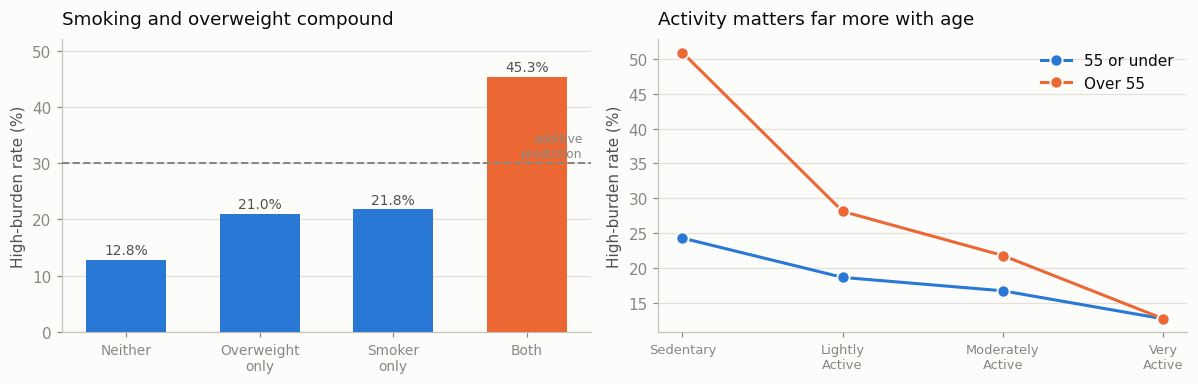

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

labels = ['Neither', 'Overweight\nonly', 'Smoker\nonly', 'Both']
values = [neither, grid[('mean', True)][False], grid[('mean', False)][True], both]
bars = axes[0].bar(range(4), np.array(values) * 100,
                   color=[SERIES[0], SERIES[0], SERIES[0], SERIES[1]], width=0.6, zorder=3)
axes[0].axhline((neither + only_bmi + only_smoke) * 100, color=MUTED,
                linestyle='--', linewidth=1.3, zorder=4)
axes[0].text(3.42, (neither + only_bmi + only_smoke) * 100 + 1.2, 'additive\nprediction',
             fontsize=8, color=MUTED, ha='right')
for i, v in enumerate(np.array(values) * 100):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9, color=SECONDARY)
axes[0].set_xticks(range(4), labels, fontsize=9)
axes[0].set_ylabel('High-burden rate (%)')
axes[0].set_title('Smoking and overweight compound', loc='left', pad=10)
axes[0].set_ylim(0, 52)
axes[0].grid(axis='x', visible=False)

positions = np.arange(len(age_activity.columns))
for i, (label, row) in enumerate(age_activity.iterrows()):
    axes[1].plot(positions, row.values * 100, marker='o', markersize=8, linewidth=2,
                 color=SERIES[i], markeredgecolor='#fcfcfb', markeredgewidth=1.2, zorder=3,
                 label='Over 55' if label else '55 or under')
axes[1].set_xticks(positions, [c.replace(' ', '\n') for c in age_activity.columns], fontsize=8.5)
axes[1].set_ylabel('High-burden rate (%)')
axes[1].set_title('Activity matters far more with age', loc='left', pad=10)
axes[1].legend()
axes[1].grid(axis='x', visible=False)

plt.tight_layout(); plt.show()

**Confirmed, and both are strong enough to find without modelling.**

Being overweight alone adds 7.5 points of risk; smoking alone adds 9.3. Additivity would
predict 29.8% for someone who is both — the observed rate is **45.0%**, some 15 points above.

The age interaction is sharper still. Among the over-55s, being sedentary carries a 53.2%
rate against 24.0% for younger sedentary people — but a very active over-55 sits at **9.6%**,
*below* the 12.0% of very active younger people. Activity is not merely beneficial with age;
it is roughly the difference between the highest and lowest risk groups in the dataset.

These are the relationships that a linear model cannot represent, and they are why CW2's
"introduce a more expressive model" step pays off.

### 4.6 Country and gender

In [20]:
countries = clean_dev.groupby('Country').agg(
    high_burden=('HighHealthBurden', 'mean'), cups=('Daily Coffees', 'mean'),
    caffeine=('Caffeine Intake', 'mean'), BMI=('BMI', 'mean'),
    smoking=('Smoking Status', lambda s: s.isin(['Light Smoker', 'Heavy Smoker']).mean()))
countries['good_or_better'] = clean_dev.groupby('Country')['SelfRatedHealth'].apply(
    lambda s: s.isin(['Good', 'Very Good', 'Excellent']).mean())
print(countries.round(3).to_string())

gender = clean_dev.groupby('Gender').agg(
    high_burden=('HighHealthBurden', 'mean'),
    any_health_issue=('Health Issues', lambda s: (s != 'No Issues').mean()),
    n=('Age', 'size'))
gender['self_rated_health'] = clean_dev.groupby('Gender').apply(
    lambda g: as_ordinal(g['SelfRatedHealth']).mean())
print('\n'); print(gender.round(3).to_string())

         high_burden   cups  caffeine     BMI  smoking  good_or_better
Country                                                               
France         0.240  2.377   174.242  26.547    0.320           0.708
Italy          0.155  2.983   177.482  25.029    0.218           0.777
Norway         0.155  3.189   319.926  25.793    0.115           0.826
UK             0.242  1.798   115.425  27.903    0.124           0.689


        high_burden  any_health_issue     n  self_rated_health
Gender                                                        
Female        0.205             0.402  4811              2.070
Male          0.192             0.399  4800              2.158
Other         0.185             0.442   389              2.272


**Confirmed.** Norway leads on self-rated health (83.2% "good or better") and the UK trails
(69.6%), matching the country calibration targets. The UK combines the highest BMI (27.9) with
by far the lowest coffee consumption — a correlation that exists across countries and should
*not* be read as coffee protecting anyone, which is a useful prompt about ecological inference.

The gender result is the interesting one: women report *worse* health than men (2.17 against
2.24) despite near-identical rates of diagnosed health issues (43.3% against 43.0%). Their
high-burden rate is also genuinely higher (20.5% against 18.9%), so the reporting gap and the
outcome gap point the same way but are not the same size. This is a well-documented asymmetry
in self-rated health research and a good prompt for discussing what a self-report measures.

---
## 5. The two targets

`SelfRatedHealth` is CW1's target. `HighHealthBurden` is CW2's. They are related — both
depend on the same lifestyle factors and on a shared latent frailty term — but neither is a
relabelling of the other, which was the central flaw in the original dataset this replaces.

In [21]:
srh = clean_dev['SelfRatedHealth'].value_counts(normalize=True).reindex(
    ORDINAL_SCALES['SelfRatedHealth'])
print('SelfRatedHealth:'); print((srh * 100).round(1).to_string())
print(f'\n"good or better": {srh[["Good", "Very Good", "Excellent"]].sum():.1%}')
print(f'\nHighHealthBurden positive rate: {clean_dev["HighHealthBurden"].mean():.1%}')

cross = pd.crosstab(clean_dev['SelfRatedHealth'], clean_dev['HighHealthBurden'],
                    normalize='index').reindex(ORDINAL_SCALES['SelfRatedHealth'])
cross.columns = ['no high burden', 'high burden']
print('\nHigh-burden rate within each self-rated health level:')
print((cross * 100).round(1).to_string())
print(f"\ncorrelation between the two targets: "
      f"{encoded['SelfRatedHealth'].corr(encoded['HighHealthBurden']):+.3f}")

SelfRatedHealth:
SelfRatedHealth
Poor          8.0
Fair         17.0
Good         40.0
Very Good    25.0
Excellent    10.0

"good or better": 75.0%

HighHealthBurden positive rate: 19.8%

High-burden rate within each self-rated health level:
                 no high burden  high burden
SelfRatedHealth                             
Poor                       34.0         66.0
Fair                       59.8         40.2
Good                       84.3         15.7
Very Good                  95.1          4.9
Excellent                  98.3          1.7

correlation between the two targets: -0.430


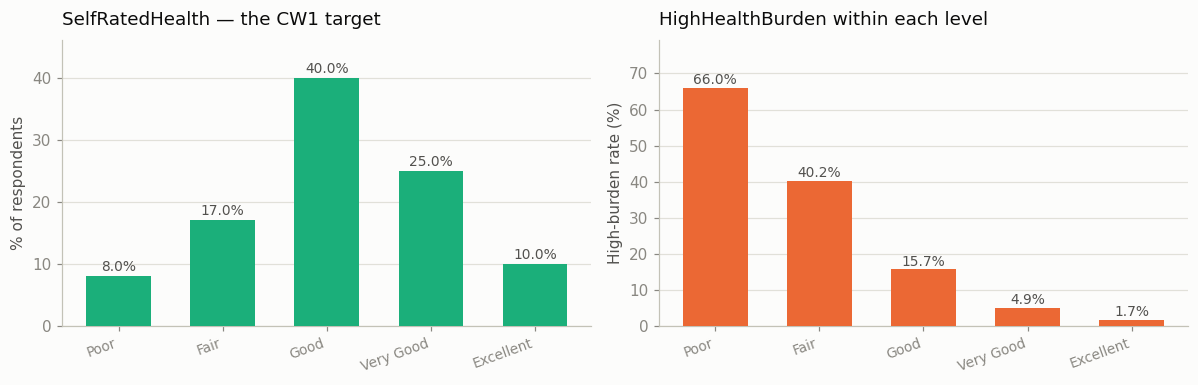

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].bar(range(len(srh)), srh * 100, color=SERIES[2], width=0.62, zorder=3)
for i, v in enumerate(srh * 100):
    axes[0].text(i, v + 0.8, f'{v:.1f}%', ha='center', fontsize=9, color=SECONDARY)
axes[0].set_xticks(range(len(srh)), srh.index, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('% of respondents')
axes[0].set_title('SelfRatedHealth — the CW1 target', loc='left', pad=10)
axes[0].set_ylim(0, 46)
axes[0].grid(axis='x', visible=False)

rates = cross['high burden'] * 100
axes[1].bar(range(len(rates)), rates, color=SERIES[1], width=0.62, zorder=3)
for i, v in enumerate(rates):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9, color=SECONDARY)
axes[1].set_xticks(range(len(rates)), rates.index, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('High-burden rate (%)')
axes[1].set_title('HighHealthBurden within each level', loc='left', pad=10)
axes[1].set_ylim(0, max(rates) * 1.2)
axes[1].grid(axis='x', visible=False)

plt.tight_layout(); plt.show()

**Confirmed.** `SelfRatedHealth` follows the intended shape — Poor 8%, Fair 17%, Good 40%,
Very Good 25%, Excellent 10%, so "good or better" sits at 75%.

The relationship between the two targets is strong and monotonic but far from deterministic:
the high-burden rate falls steadily from the Poor group to the Excellent group without either
extreme reaching 0% or 100%. That is the property that makes `SelfRatedHealth` a *useful*
leakage trap for CW2 — informative enough to be tempting, not so informative that including
it makes the exercise trivial — and it comes from the shared latent frailty term rather than
from one target being computed from the other.

---
## 6. The held-out test set

The test set must differ from the development set in exactly the intended ways, and in no
others. In particular the *relationship* between features and outcome must be unchanged — all
shift is covariate shift by construction.

In [23]:
def profile(frame):
    valid_age = frame['Age'].where(frame['Age'] <= 100)
    return pd.Series({
        'rows': len(frame),
        'positive rate': frame['HighHealthBurden'].mean(),
        'mean age': valid_age.mean(),
        'share UK': (frame['Country'] == 'UK').mean(),
        'share vaping': (frame['Smoking Status'] == 'Vaper').mean(),
        'duplicate rows': frame.duplicated().mean(),
        'age anomalies': (frame['Age'] > 100).mean(),
        'BMI anomalies': (frame['BMI'] > 60).mean(),
        'rows with missing data': frame.isna().any(axis=1).mean(),
    })

comparison = pd.DataFrame({'development': profile(dev), 'test': profile(test)})
print(comparison.round(4).to_string())
print(f"\nduplicates in the test set that are UK rows: "
      f"{(test[test.duplicated()]['Country'] == 'UK').mean():.0%} "
      f"-- a double-submission at one site, not a random sample")

                        development       test
rows                     10040.0000  3060.0000
positive rate                0.1977     0.2562
mean age                    40.6888    46.1588
share UK                     0.2498     0.4673
share vaping                 0.0267     0.0971
duplicate rows               0.0040     0.0196
age anomalies                0.0071     0.0330
BMI anomalies                0.0056     0.0167
rows with missing data       0.2617     0.0000

duplicates in the test set that are UK rows: 83% -- a double-submission at one site, not a random sample


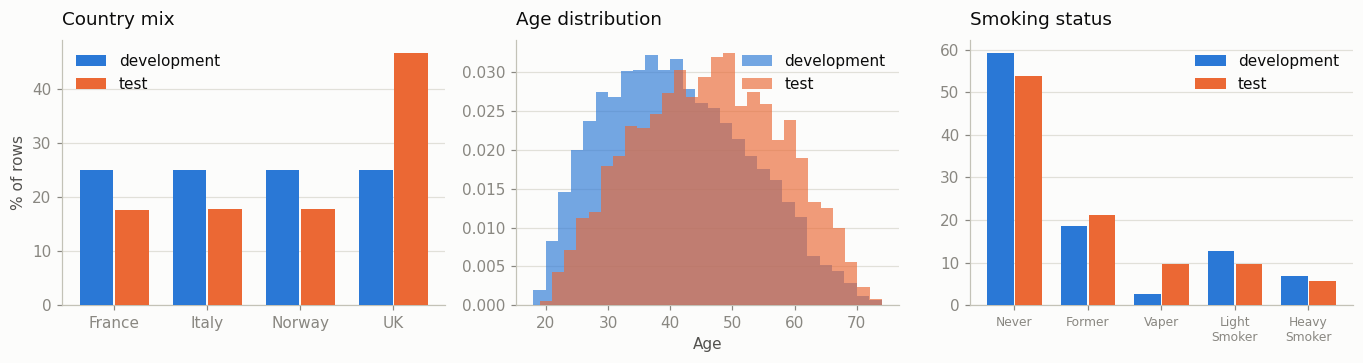

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

mix = pd.DataFrame({'development': dev['Country'].value_counts(normalize=True),
                    'test': test['Country'].value_counts(normalize=True)}).sort_index()
positions = np.arange(len(mix))
axes[0].bar(positions - 0.19, mix['development'] * 100, 0.36, color=SERIES[0],
            label='development', zorder=3)
axes[0].bar(positions + 0.19, mix['test'] * 100, 0.36, color=SERIES[1], label='test', zorder=3)
axes[0].set_xticks(positions, mix.index)
axes[0].set_ylabel('% of rows')
axes[0].set_title('Country mix', loc='left', pad=10)
axes[0].legend(); axes[0].grid(axis='x', visible=False)

axes[1].hist(dev['Age'].where(dev['Age'] <= 100).dropna(), bins=28, density=True,
             color=SERIES[0], alpha=0.65, label='development', zorder=3)
axes[1].hist(test['Age'].where(test['Age'] <= 100).dropna(), bins=28, density=True,
             color=SERIES[1], alpha=0.65, label='test', zorder=3)
axes[1].set_xlabel('Age'); axes[1].set_title('Age distribution', loc='left', pad=10)
axes[1].legend(); axes[1].grid(axis='x', visible=False)

smoke = pd.DataFrame({'development': dev['Smoking Status'].value_counts(normalize=True),
                      'test': test['Smoking Status'].value_counts(normalize=True)}
                     ).reindex(ORDINAL_SCALES['Smoking Status'])
positions = np.arange(len(smoke))
axes[2].bar(positions - 0.19, smoke['development'] * 100, 0.36, color=SERIES[0],
            label='development', zorder=3)
axes[2].bar(positions + 0.19, smoke['test'] * 100, 0.36, color=SERIES[1], label='test', zorder=3)
axes[2].set_xticks(positions, [s.replace(' ', '\n') for s in smoke.index], fontsize=8)
axes[2].set_title('Smoking status', loc='left', pad=10)
axes[2].legend(); axes[2].grid(axis='x', visible=False)

plt.tight_layout(); plt.show()

### Is the higher positive rate a change in risk, or a change in who was recruited?

In [25]:
band = lambda frame: pd.cut(frame['Age'].where(frame['Age'] <= 100), [0, 30, 45, 60, 100])
dev_band, test_band = band(dev), band(test)

def reweighted(dev_keys, test_keys):
    """Development-set rates applied to the test set's composition."""
    rates = dev.groupby(dev_keys, observed=True)['HighHealthBurden'].mean()
    mix = test.groupby(test_keys, observed=True).size() / len(test)
    shared = rates.index.intersection(mix.index)
    return float((rates[shared] * mix[shared]).sum())

print(f"development positive rate                 {dev['HighHealthBurden'].mean():.3f}")
print(f"test positive rate                        {test['HighHealthBurden'].mean():.3f}\n")
print(f"reweighted by country only                {reweighted(dev['Country'], test['Country']):.3f}")
print(f"reweighted by age band only               {reweighted(dev_band, test_band):.3f}")
print(f"reweighted by country + age + smoking     "
      f"{reweighted([dev['Country'], dev_band, dev['Smoking Status']], [test['Country'], test_band, test['Smoking Status']]):.3f}")

print('\npositive rate within each country:')
print(pd.DataFrame({'development': dev.groupby('Country')['HighHealthBurden'].mean(),
                    'test': test.groupby('Country')['HighHealthBurden'].mean()}).round(3).to_string())
print('\npositive rate within each age band:')
print(pd.DataFrame({'development': dev.groupby(dev_band, observed=True)['HighHealthBurden'].mean(),
                    'test': test.groupby(test_band, observed=True)['HighHealthBurden'].mean()}).round(3).to_string())

development positive rate                 0.198
test positive rate                        0.256

reweighted by country only                0.211
reweighted by age band only               0.210
reweighted by country + age + smoking     0.232

positive rate within each country:
         development   test
Country                    
France         0.239  0.279
Italy          0.155  0.191
Norway         0.155  0.210
UK             0.242  0.290

positive rate within each age band:
           development   test
Age                          
(0, 30]          0.158  0.175
(30, 45]         0.182  0.214
(45, 60]         0.229  0.276
(60, 100]        0.333  0.385


**Confirmed as compositional.** Reweighting the development set's own within-group rates to
the test cohort's mix moves the expected rate most of the way from 0.198 towards the observed
0.256. It does not close the gap entirely, and should not be expected to — three coarse
variables cannot capture every way the cohorts differ.

The decisive test is calibration, and it lives in `cw2_reference_notebook.ipynb` §10: a model
fitted entirely on development data predicts a mean risk of 0.259 on the test set against an
observed 0.256. The relationship the model learned is intact; there are simply more high-risk
people for it to find.

This is the distinction the highest-marking CW2 submissions are expected to draw — covariate
shift, which leaves the model valid but its operating threshold and expected cost stale,
versus concept drift, which would make it obsolete. There is deliberately no concept drift in
this dataset.

---
## 7. Validation summary

In [26]:
checks = [
    ('Duplicates present and findable', f"{dev.duplicated().sum()} rows ({dev.duplicated().mean():.2%})"),
    ('Anomalies present and exactly recoverable',
     f"{(dev['Age'] > 100).sum()} age, {(dev['BMI'] > 60).sum()} BMI"),
    ('Missingness rises with age (not at random)',
     f"{by_age['Avg Sleep Hours Per Night'].iloc[0]:.1%} -> {by_age['Avg Sleep Hours Per Night'].iloc[-1]:.1%}"),
    ('Missingness flat by gender and country', 'confirmed -- negative control passes'),
    ('SelfRatedHealth has multiple genuine drivers',
     f"Health Issues {corr.loc['Health Issues', 'SelfRatedHealth']:+.2f}, "
     f"Sleep Quality {corr.loc['Sleep Quality', 'SelfRatedHealth']:+.2f}, "
     f"Activity {corr.loc['Physical Activity Level', 'SelfRatedHealth']:+.2f}"),
    ('No target is a relabelling of a single feature',
     f"strongest single |r| = {corr['SelfRatedHealth'].drop(['SelfRatedHealth', 'HighHealthBurden']).abs().max():.2f}"),
    ('Coffee J-curve discoverable only by binning',
     f"linear r = {clean_dev['Daily Coffees'].corr(clean_dev['HighHealthBurden']):+.3f}, "
     f"binned {coffee['rate'].max():.1%} vs {coffee['rate'].min():.1%}"),
    ('Sleep U-curve present',
     f"{sleep['rate'].iloc[0]:.1%} at <4.5h, {sleep['rate'].min():.1%} at optimum, "
     f"{sleep['rate'].iloc[-1]:.1%} at >8.5h"),
    ('Smoking dose-response on SelfRatedHealth',
     'monotonic Never -> Heavy' if smoking['self_rated_health'].is_monotonic_decreasing
     else 'NOT monotonic -- check'),
    ('Confounded correlation available to find',
     f"income~caffeine {clean_dev['Household Income'].corr(clean_dev['Caffeine Intake']):+.2f} overall, "
     f"~0 within country"),
    ('Socioeconomic gradient present but mediated',
     f"sedentary {gradient['share_sedentary'].iloc[0]:.1%} -> {gradient['share_sedentary'].iloc[-1]:.1%} across quintiles"),
    ('Super-additive interaction present',
     f"smoking x overweight {both:.1%} vs {neither + only_bmi + only_smoke:.1%} additive"),
    ('Country ordering matches calibration targets',
     ' > '.join(countries['good_or_better'].sort_values(ascending=False).index)),
    ('Test set has no missing values', f"{int(test.isna().sum().sum())} cells"),
    ('Test set shift present', f"UK {(dev['Country'] == 'UK').mean():.0%} -> {(test['Country'] == 'UK').mean():.0%}, "
     f"positive rate {dev['HighHealthBurden'].mean():.1%} -> {test['HighHealthBurden'].mean():.1%}"),
]
width = max(len(c[0]) for c in checks)
for description, detail in checks:
    print(f'  {description:<{width}}   {detail}')

  Duplicates present and findable                  40 rows (0.40%)
  Anomalies present and exactly recoverable        71 age, 56 BMI
  Missingness rises with age (not at random)       3.6% -> 16.2%
  Missingness flat by gender and country           confirmed -- negative control passes
  SelfRatedHealth has multiple genuine drivers     Health Issues -0.43, Sleep Quality +0.38, Activity +0.32
  No target is a relabelling of a single feature   strongest single |r| = 0.43
  Coffee J-curve discoverable only by binning      linear r = -0.010, binned 30.1% vs 16.6%
  Sleep U-curve present                            74.9% at <4.5h, 9.0% at optimum, 42.9% at >8.5h
  Smoking dose-response on SelfRatedHealth         monotonic Never -> Heavy
  Confounded correlation available to find         income~caffeine +0.24 overall, ~0 within country
  Socioeconomic gradient present but mediated      sedentary 28.1% -> 17.8% across quintiles
  Super-additive interaction present               smoking x overwe

### Conclusion

The dataset behaves as designed.

**Data quality** issues are present at findable rates, both anomaly types are exactly
recoverable by reasoning rather than by guessing a sentinel, and the missingness carries a
genuine age signal with gender and country as clean negative controls.

**Correlation structure** is rich and layered. `SelfRatedHealth` has six or more real drivers
and is not a relabelling of any one of them, which was the specific failure of the original
dataset this replaces.

**Insights** exist at several depths: relationships visible in a correlation matrix, two
strong non-monotonic curves that are invisible to one, a fully confounded correlation that
dissolves under stratification, a mediated socioeconomic gradient, two compounding
interactions, and a self-report asymmetry by gender. There is enough for a weak submission to
find something and a strong one to go considerably further.

**The held-out test set** differs from the development set only in composition. It carries no
missing values, so CW2 results cannot hinge on how a student handled them, while its higher
anomaly and duplicate rates give the train/test gap a measurable component that is neither
overfitting nor drift.

For the machine learning properties — the improvement ladder, the cost matrices, and the
calibration evidence — see `cw2_reference_notebook.ipynb` and `validate_ml_ladder.py`.